# V2a-RSNs Clustered IC Selection from Saved Linear Decompositions

This notebook starts from the decomposition artifacts saved by `linear_methods.ipynb` and only performs spectral clustering, cluster-level IC selection, and trace reconstruction. Run `linear_methods.ipynb` first with `SAVE_DECOMPOSITION_OUTPUTS = True`; this notebook then reads `components`, `spectra`, `mixing`, `mean`, and `metadata` from `outputs/linear/<dataset_group>/<data_name>/<method>/`.

Clustered cleaned traces are saved under `outputs/linear/<dataset_group>/<data_name>/<method>/cleaned/`, and cluster-selection JSON is saved under `outputs/linear/<dataset_group>/<data_name>/<method>/clusters/` when `SAVE_OUTPUTS = True`.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    p
    for p in candidates
    if (p / "pyproject.toml").exists() and (p / "src" / "bss_notebook.py").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
CORE_DIR = SRC_DIR / "core"
for path in (SRC_DIR, CORE_DIR):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from bss_notebook import (
    BSS_METHODS,
    available_datasets,
    load_bss_decomposition_outputs,
    load_traces,
    output_directory,
    save_cleaned_trace_output,
    save_cluster_selection_output,
    summarize_decomposition_results,
)
from ica_utils import (
    cluster,
    rank_clusters_by_mean_log_psd,
    reconstruct_bss,
    reject_components_from_cluster_selection,
)

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PROJECT_ROOT


PosixPath('/Users/sadiq.adedayo/Documents/projects/others/ica-denoising')

In [2]:
available_datasets(PROJECT_ROOT)


,key,group,data_name,trace_path,exists,default_n_components,sample_rate_hz,notes
0,motorneurons/fish3_trace2_dff,motorneurons,fish3_trace2_dff,/Users/sadiq.adedayo/Documents/projects/others...,True,11,4.0000,Motorneuron dF/F traces.
1,motorneurons/gcM_restored,motorneurons,gcM_restored,/Users/sadiq.adedayo/Documents/projects/others...,True,11,4.0000,Restored motorneuron traces.
2,v2a-RSNs/220127_F4_run2_fluorescence,v2a-RSNs,220127_F4_run2_fluorescence,/Users/sadiq.adedayo/Documents/projects/others...,True,40,5.2962,V2a RSN fluorescence traces.
3,v2a-RSNs/220127_F4_run2_spike_rate,v2a-RSNs,220127_F4_run2_spike_rate,/Users/sadiq.adedayo/Documents/projects/others...,True,40,5.2962,V2a RSN spike-rate traces.
4,v2a-RSNs/220210_F1_run6_fluorescence,v2a-RSNs,220210_F1_run6_fluorescence,/Users/sadiq.adedayo/Documents/projects/others...,True,40,5.2962,V2a RSN fluorescence traces. Uses frameRateSCA...
5,v2a-RSNs/220210_F1_run6_spike_rate,v2a-RSNs,220210_F1_run6_spike_rate,/Users/sadiq.adedayo/Documents/projects/others...,True,40,5.2962,V2a RSN spike-rate traces. Uses frameRateSCAPE...


In [3]:
# Dataset and method selection
DATASET_KEY = "v2a-RSNs/220127_F4_run2_fluorescence"

# Choose methods to load from saved linear decompositions.
# Missing methods are skipped automatically later in the notebook.
METHODS_TO_RUN = list(BSS_METHODS)  # e.g. ["fastica", "infomax"]

# Read decomposition artifacts produced by notebooks/v2a-RSNs/linear_methods.ipynb.
SOURCE_ANALYSIS_KIND = "linear"

# Clustered output layout:
#   outputs/linear/<dataset_group>/<data_name>/<method>/cleaned/
#   outputs/linear/<dataset_group>/<data_name>/<method>/clusters/
OUTPUT_ANALYSIS_KIND = "linear"

# Cluster ICs by Welch-spectrum features, matching the reference ICA notebook's clustering workflow.
N_CLUSTERS = 7
CLUSTER_FEATURE_START_BIN = 30
CLUSTER_NPERSEG = 250
CLUSTER_NOVERLAP = 125
CLUSTER_RANDOM_STATE = 0

# Set True after cluster rejection choices are final.
SAVE_OUTPUTS = True


In [4]:
dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
n_neurons, n_frames = traces.shape
sample_rate_hz = dataset.sample_rate_hz or 1.0

print(f"dataset: {dataset.key}")
print(f"trace file: {dataset.trace_path.relative_to(PROJECT_ROOT)}")
print(f"traces: neurons={n_neurons}, frames={n_frames}")
print(f"methods: {METHODS_TO_RUN}")
for method in METHODS_TO_RUN:
    method_dir = output_directory(
        method,
        dataset.data_name,
        PROJECT_ROOT,
        analysis_kind=OUTPUT_ANALYSIS_KIND,
        dataset_group=dataset.group,
    )
    print(f"{method} linear decomposition dir: {method_dir.relative_to(PROJECT_ROOT)}")
    print(f"{method} cleaned output dir: {(method_dir / 'cleaned').relative_to(PROJECT_ROOT)}")
    print(f"{method} cluster metadata dir: {(method_dir / 'clusters').relative_to(PROJECT_ROOT)}")


dataset: v2a-RSNs/220127_F4_run2_fluorescence
trace file: data/v2a-RSNs/new_data_09112022/220127_F4_run2/220127_F4_F4_run2_after_dec_cells_fluorescence_signals.npy
traces: neurons=844, frames=3176
methods: ['fastica', 'infomax', 'sobi', 'jade']
fastica linear decomposition dir: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica
fastica cleaned output dir: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/cleaned
fastica cluster metadata dir: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/clusters
infomax linear decomposition dir: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/infomax
infomax cleaned output dir: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/infomax/cleaned
infomax cluster metadata dir: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/infomax/clusters
sobi linear decomposition dir: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/sobi
sobi cleaned output dir: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/sobi/cleaned

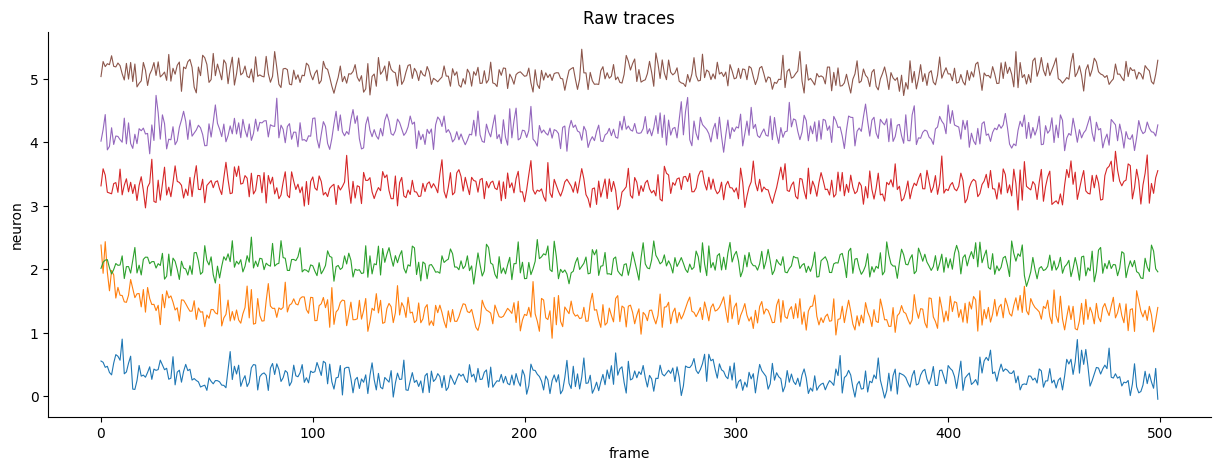

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))
time_slice = slice(0, min(500, n_frames))
shown_neurons = list(range(min(6, n_neurons)))
offset = np.nanstd(traces[:, time_slice]) * 0.4
if not np.isfinite(offset) or offset == 0:
    offset = 1.0

for row_idx, neuron_idx in enumerate(shown_neurons):
    ax.plot(
        np.arange(time_slice.start, time_slice.stop),
        traces[neuron_idx, time_slice] + row_idx * offset,
        lw=0.8,
    )

ax.set_title("Raw traces")
ax.set_xlabel("frame")
ax.set_ylabel("neuron")
ax.set_yticks([row_idx * offset for row_idx in range(len(shown_neurons))])
ax.set_yticklabels([str(neuron_idx) for neuron_idx in shown_neurons]);


In [6]:
import time

results = {}
source_metadata_by_method = {}
skipped_methods = {}
total_methods = len(METHODS_TO_RUN)
load_start = time.perf_counter()

for idx, method in enumerate(METHODS_TO_RUN, start=1):
    t0 = time.perf_counter()
    print(f"[{idx}/{total_methods}] Loading saved linear decomposition artifacts for {method}...")
    try:
        result = load_bss_decomposition_outputs(
            dataset_key=DATASET_KEY,
            method=method,
            project_root=PROJECT_ROOT,
            analysis_kind=SOURCE_ANALYSIS_KIND,
        )
    except FileNotFoundError as exc:
        skipped_methods[method] = str(exc).splitlines()[0]
        print(f"[{idx}/{total_methods}] Skipping {method}: saved decomposition outputs not found")
        continue
    results[method] = result
    metadata_path = result.saved_paths["metadata"]
    source_metadata_by_method[method] = json.loads(metadata_path.read_text(encoding="utf-8"))
    dt = time.perf_counter() - t0
    print(
        f"[{idx}/{total_methods}] Loaded {method} in {dt:.1f}s "
        f"(ICs={result.ic_comps.shape}, mixing={result.A.shape})"
    )

loaded_methods = len(results)
if skipped_methods:
    print("Skipped methods (missing saved outputs):")
    for method, reason in skipped_methods.items():
        print(f"  - {method}: {reason}")

if loaded_methods == 0:
    raise FileNotFoundError(
        "No saved linear decomposition outputs found for METHODS_TO_RUN. "
        "Run notebooks/v2a-RSNs/linear_methods.ipynb with SAVE_DECOMPOSITION_OUTPUTS = True "
        "or set METHODS_TO_RUN to methods with existing saved outputs."
    )

print(
    f"Loaded saved linear decomposition artifacts for {loaded_methods}/{total_methods} methods "
    f"in {time.perf_counter() - load_start:.1f}s"
)
summarize_decomposition_results(results)


[1/4] Loading saved linear decomposition artifacts for fastica...
[1/4] Loaded fastica in 0.1s (ICs=(3176, 844), mixing=(844, 844))
[2/4] Loading saved linear decomposition artifacts for infomax...
[2/4] Loaded infomax in 0.1s (ICs=(3176, 844), mixing=(844, 844))
[3/4] Loading saved linear decomposition artifacts for sobi...
[3/4] Loaded sobi in 0.0s (ICs=(3176, 400), mixing=(844, 400))
[4/4] Loading saved linear decomposition artifacts for jade...
[4/4] Loaded jade in 0.1s (ICs=(3176, 400), mixing=(844, 400))
Loaded saved linear decomposition artifacts for 4/4 methods in 0.2s


,method,dataset_key,data_name,dataset_group,input_shape,components_shape,spectra_shape,mixing_shape,mean_shape,output_dir,saved
0,fastica,v2a-RSNs/220127_F4_run2_fluorescence,220127_F4_run2_fluorescence,v2a-RSNs,"(844, 3176)","(3176, 844)","(844, 3176)","(844, 844)","(844,)",/Users/sadiq.adedayo/Documents/projects/others...,True
1,infomax,v2a-RSNs/220127_F4_run2_fluorescence,220127_F4_run2_fluorescence,v2a-RSNs,"(844, 3176)","(3176, 844)","(844, 3176)","(844, 844)","(844,)",/Users/sadiq.adedayo/Documents/projects/others...,True
2,sobi,v2a-RSNs/220127_F4_run2_fluorescence,220127_F4_run2_fluorescence,v2a-RSNs,"(844, 3176)","(3176, 400)","(400, 3176)","(844, 400)","(844,)",/Users/sadiq.adedayo/Documents/projects/others...,True
3,jade,v2a-RSNs/220127_F4_run2_fluorescence,220127_F4_run2_fluorescence,v2a-RSNs,"(844, 3176)","(3176, 400)","(400, 3176)","(844, 400)","(844,)",/Users/sadiq.adedayo/Documents/projects/others...,True


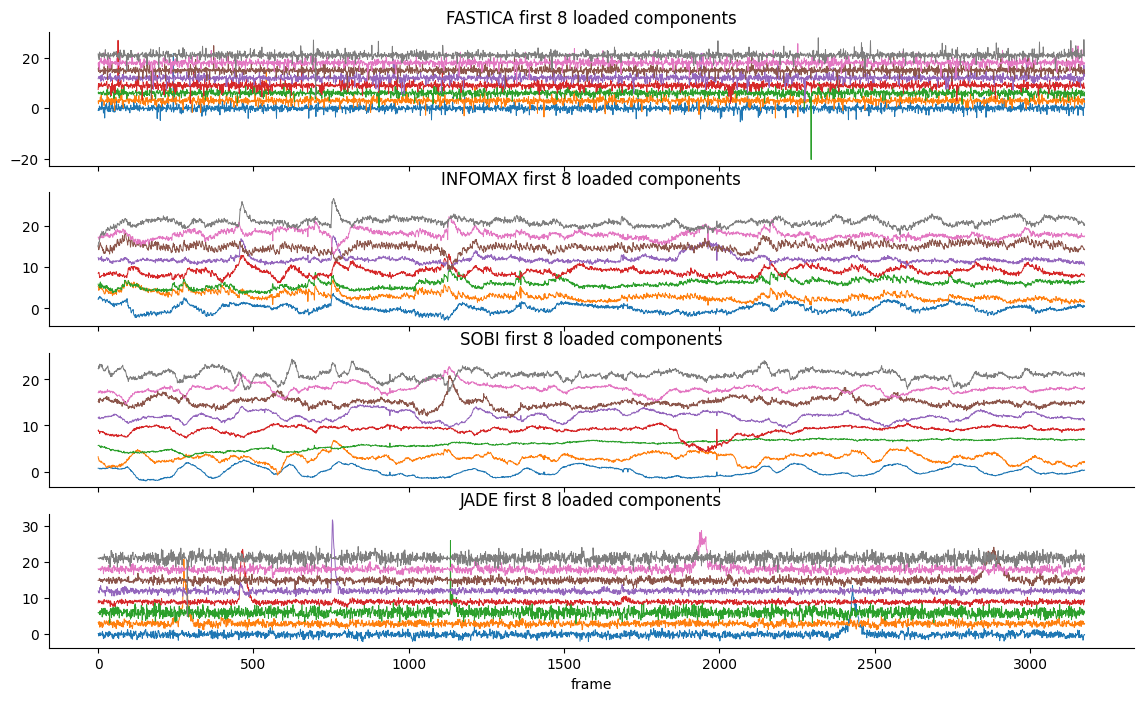

In [7]:
component_count = min(8, max(result.ic_comps.shape[1] for result in results.values()))
fig, axes = plt.subplots(len(results), 1, figsize=(14, 2.0 * len(results)), sharex=True)
if len(results) == 1:
    axes = [axes]
for ax, (method, result) in zip(axes, results.items()):
    for comp_idx in range(min(component_count, result.ic_comps.shape[1])):
        ax.plot(result.ic_comps[:, comp_idx] + comp_idx * 3, lw=0.7, label=f"IC {comp_idx}")
    ax.set_title(f"{method.upper()} first {component_count} loaded components")
axes[-1].set_xlabel("frame");


In [8]:
import time

cluster_results = {}
cluster_rows = []
total_methods = len(results)
cluster_start = time.perf_counter()

for idx, (method, result) in enumerate(results.items(), start=1):
    t0 = time.perf_counter()
    print(f"[{idx}/{total_methods}] Clustering ICs for {method}...")
    new_mat, predictions, spectra, features = cluster(
        result.ic_comps,
        N_CLUSTERS,
        sample_rate_hz,
        feature_start_bin=CLUSTER_FEATURE_START_BIN,
        nperseg=CLUSTER_NPERSEG,
        noverlap=CLUSTER_NOVERLAP,
        random_state=CLUSTER_RANDOM_STATE,
    )
    cluster_results[method] = {
        "new_mat": new_mat,
        "predictions": predictions,
        "spectra": spectra,
        "features": features,
    }
    for cluster_id in sorted(np.unique(predictions)):
        ic_indices = np.flatnonzero(predictions == cluster_id)
        cluster_rows.append(
            {
                "method": method,
                "cluster": int(cluster_id),
                "n_ics": int(ic_indices.size),
                "ic_indices": ic_indices.tolist(),
            }
        )
    dt = time.perf_counter() - t0
    print(f"[{idx}/{total_methods}] Finished clustering {method} in {dt:.1f}s")

print(f"Completed clustering for {total_methods} methods in {time.perf_counter() - cluster_start:.1f}s")
pd.DataFrame(cluster_rows)


[1/4] Clustering ICs for fastica...
[1/4] Finished clustering fastica in 0.2s
[2/4] Clustering ICs for infomax...
[2/4] Finished clustering infomax in 0.2s
[3/4] Clustering ICs for sobi...
[3/4] Finished clustering sobi in 0.1s
[4/4] Clustering ICs for jade...
[4/4] Finished clustering jade in 0.1s
Completed clustering for 4 methods in 0.7s


,method,cluster,n_ics,ic_indices
0,fastica,0,77,"[10, 21, 35, 36, 42, 45, 52, 63, 82, 83, 104, ..."
1,fastica,1,138,"[0, 11, 20, 27, 30, 39, 44, 50, 62, 68, 77, 84..."
2,fastica,2,140,"[2, 3, 7, 12, 14, 25, 43, 48, 54, 55, 72, 85, ..."
3,fastica,3,126,"[4, 9, 15, 33, 49, 53, 58, 61, 71, 75, 76, 78,..."
4,fastica,4,159,"[5, 13, 16, 26, 28, 29, 31, 34, 37, 38, 47, 59..."
5,fastica,5,28,"[8, 19, 46, 66, 73, 74, 90, 153, 265, 310, 323..."
6,fastica,6,176,"[1, 6, 17, 18, 22, 23, 24, 32, 40, 41, 51, 56,..."
7,infomax,0,181,"[61, 64, 67, 71, 72, 74, 76, 79, 80, 81, 84, 8..."
8,infomax,1,30,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
9,infomax,2,197,"[153, 201, 205, 212, 218, 220, 227, 230, 234, ..."


fastica
  Peak log-PSD rank near 0 Hz (high→low): [0, 5, 2, 1, 4, 6, 3]


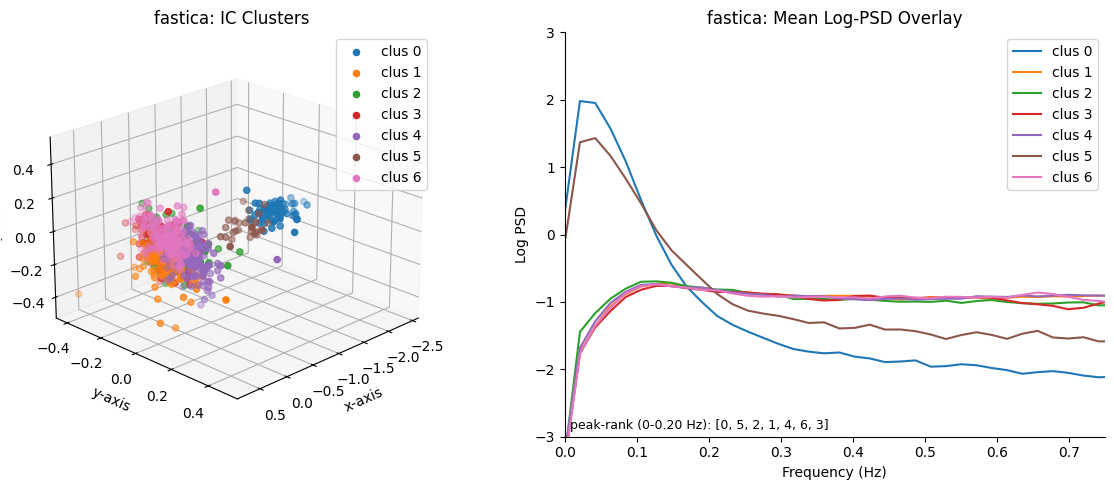

infomax
  Peak log-PSD rank near 0 Hz (high→low): [1, 5, 3, 0, 2, 6, 4]


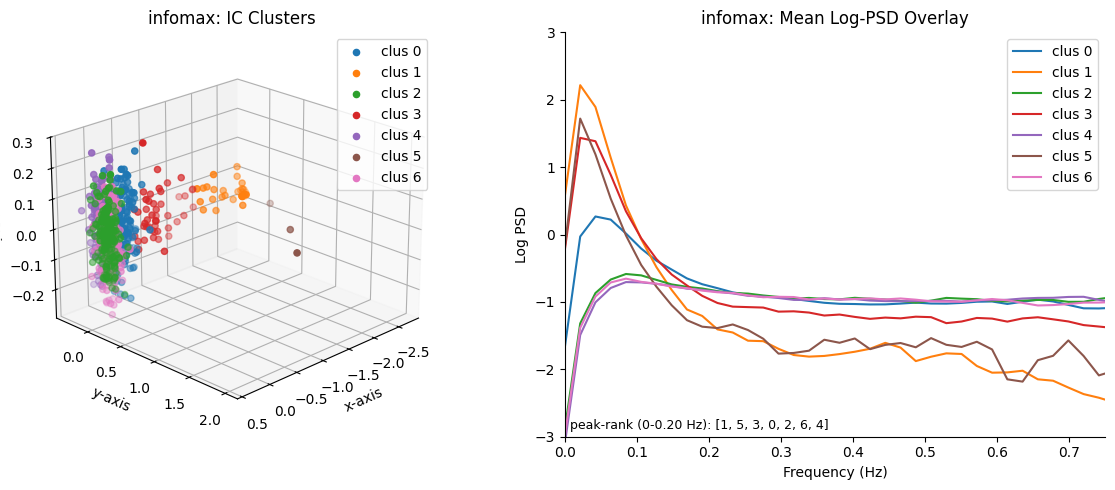

sobi
  Peak log-PSD rank near 0 Hz (high→low): [2, 4, 1, 6, 3, 5, 0]


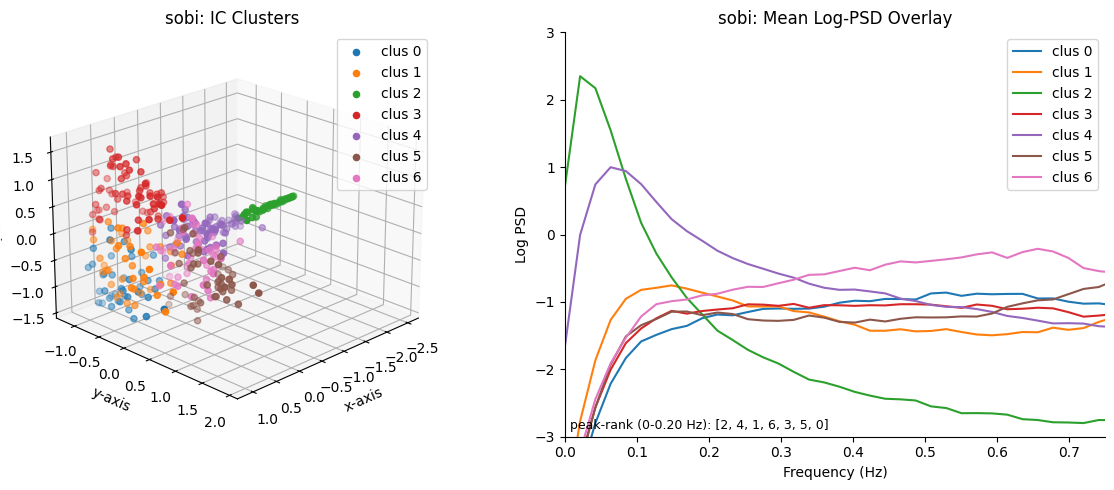

jade
  Peak log-PSD rank near 0 Hz (high→low): [4, 5, 3, 0, 6, 1, 2]


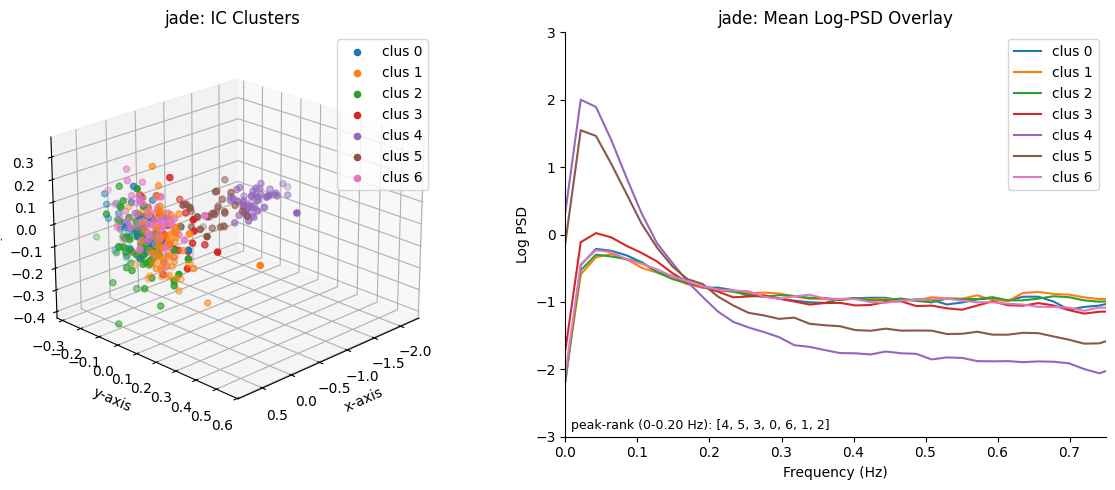

In [9]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

for method, clustered in cluster_results.items():
    print(method)

    new_mat = clustered["new_mat"]
    predictions = clustered["predictions"]
    spectra = clustered["spectra"]

    ranked = rank_clusters_by_mean_log_psd(
        spectra,
        predictions,
        sample_rate_hz,
        fmin=0.0,
        fmax=0.20,
        aggregate="peak",
    )
    ordered_clusters = [row["cluster"] for row in ranked]
    print(f"  Peak log-PSD rank near 0 Hz (high→low): {ordered_clusters}")

    fig = plt.figure(figsize=(12, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.0])

    # Left: 3D cluster scatter
    ax3d = fig.add_subplot(gs[0, 0], projection="3d")
    for label in np.unique(predictions):
        pts = new_mat[predictions == label]
        ax3d.scatter(pts[:, 0], pts[:, 1], pts[:, 2], label=f"clus {int(label)}")
    ax3d.set_xlabel("x-axis")
    ax3d.set_ylabel("y-axis")
    ax3d.set_zlabel("z-axis")
    ax3d.set_title(f"{method}: IC Clusters")
    ax3d.legend(loc="best")
    ax3d.view_init(elev=22, azim=45)

    # Right: overlay of mean log-PSDs only
    ax_psd = fig.add_subplot(gs[0, 1])
    eps = np.finfo(float).eps
    freqs = np.linspace(0.0, float(sample_rate_hz) / 2.0, spectra.shape[1])
    for label in np.unique(predictions):
        group = spectra[predictions == label]
        mean_log = np.log(np.maximum(group.mean(axis=0), eps))
        ax_psd.plot(freqs, mean_log, lw=1.5, label=f"clus {int(label)}")

    ax_psd.set_xlim([0, 0.75])
    ax_psd.set_ylim([-3, 3])
    ax_psd.set_xlabel("Frequency (Hz)")
    ax_psd.set_ylabel("Log PSD")
    ax_psd.set_title(f"{method}: Mean Log-PSD Overlay")
    ax_psd.text(0.01, 0.02, f"peak-rank (0-0.20 Hz): {ordered_clusters}", transform=ax_psd.transAxes, fontsize=9)
    ax_psd.legend(loc="best")

    fig.tight_layout()
    display(fig)
    plt.close(fig)



In [10]:
# Save cluster scatter and log-spectrum diagnostic plots.
SAVE_CLUSTER_FIGURES = True
CLUSTER_FIGURE_DPI = 300

cluster_figure_paths_by_method = {}


def _cluster_rank_order(predictions, spectra):
    ranked = rank_clusters_by_mean_log_psd(
        spectra,
        predictions,
        sample_rate_hz,
        fmin=0.0,
        fmax=0.20,
        aggregate="peak",
    )
    return [int(row["cluster"]) for row in ranked]


if SAVE_CLUSTER_FIGURES:
    for method, clustered in cluster_results.items():
        result = results[method]
        method_dir = output_directory(
            method,
            result.dataset.data_name,
            PROJECT_ROOT,
            analysis_kind=OUTPUT_ANALYSIS_KIND,
            dataset_group=result.dataset.group,
        )
        cluster_dir = method_dir / "clusters"
        cluster_dir.mkdir(parents=True, exist_ok=True)

        new_mat = clustered["new_mat"]
        predictions = clustered["predictions"]
        spectra = clustered["spectra"]
        ordered_clusters = _cluster_rank_order(predictions, spectra)
        stem = f"{method}_{result.dataset.data_name}"

        fig_cluster = plt.figure(figsize=(7, 5))
        ax3d = fig_cluster.add_subplot(111, projection="3d")
        for label in np.unique(predictions):
            pts = new_mat[predictions == label]
            ax3d.scatter(pts[:, 0], pts[:, 1], pts[:, 2], label=f"clus {int(label)}")
        ax3d.set_xlabel("x-axis")
        ax3d.set_ylabel("y-axis")
        ax3d.set_zlabel("z-axis")
        ax3d.set_title(f"{method}: IC Clusters")
        ax3d.legend(loc="best")
        ax3d.view_init(elev=22, azim=45)
        fig_cluster.tight_layout()
        cluster_path = cluster_dir / f"ic_clusters_{stem}.png"
        fig_cluster.savefig(cluster_path, dpi=CLUSTER_FIGURE_DPI, bbox_inches="tight")
        plt.close(fig_cluster)

        fig_psd, ax_psd = plt.subplots(figsize=(7, 5))
        eps = np.finfo(float).eps
        freqs = np.linspace(0.0, float(sample_rate_hz) / 2.0, spectra.shape[1])
        for label in np.unique(predictions):
            group = spectra[predictions == label]
            mean_log = np.log(np.maximum(group.mean(axis=0), eps))
            ax_psd.plot(freqs, mean_log, lw=1.5, label=f"clus {int(label)}")
        ax_psd.set_xlim([0, 0.75])
        ax_psd.set_ylim([-3, 3])
        ax_psd.set_xlabel("Frequency (Hz)")
        ax_psd.set_ylabel("Log PSD")
        ax_psd.set_title(f"{method}: Mean Log-PSD Overlay")
        ax_psd.text(
            0.01,
            0.02,
            f"peak-rank (0-0.20 Hz): {ordered_clusters}",
            transform=ax_psd.transAxes,
            fontsize=9,
        )
        ax_psd.legend(loc="best")
        fig_psd.tight_layout()
        log_spectra_path = cluster_dir / f"mean_log_psd_{stem}.png"
        fig_psd.savefig(log_spectra_path, dpi=CLUSTER_FIGURE_DPI, bbox_inches="tight")
        plt.close(fig_psd)

        cluster_figure_paths_by_method[method] = {
            "cluster_scatter": cluster_path,
            "mean_log_psd": log_spectra_path,
        }
        print(f"{method} cluster scatter: {cluster_path.relative_to(PROJECT_ROOT)}")
        print(f"{method} mean log PSD: {log_spectra_path.relative_to(PROJECT_ROOT)}")
else:
    print("SAVE_CLUSTER_FIGURES is False; cluster diagnostics were not saved.")


fastica cluster scatter: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/clusters/ic_clusters_fastica_220127_F4_run2_fluorescence.png
fastica mean log PSD: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/clusters/mean_log_psd_fastica_220127_F4_run2_fluorescence.png
infomax cluster scatter: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/infomax/clusters/ic_clusters_infomax_220127_F4_run2_fluorescence.png
infomax mean log PSD: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/infomax/clusters/mean_log_psd_infomax_220127_F4_run2_fluorescence.png
sobi cluster scatter: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/sobi/clusters/ic_clusters_sobi_220127_F4_run2_fluorescence.png
sobi mean log PSD: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/sobi/clusters/mean_log_psd_sobi_220127_F4_run2_fluorescence.png
jade cluster scatter: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/jade/clusters/ic_clusters_jade_220127_F4_run2_fluorescence.png
jade mean l

In [11]:
# Set True after cluster rejection choices are final.
SAVE_OUTPUTS = True

# Selection mode:
# - "manual": use CLUSTER_SELECTION_BY_METHOD exactly.
# - "incremental_ranked": auto-build [top1], [top2], ... keep-cluster prefixes
#   from rank_clusters_by_mean_log_psd (optionally overridden per method below).
SELECTION_MODE = "incremental_ranked"

# Used only when SELECTION_MODE == "manual".
CLUSTER_SELECTION_BY_METHOD = {
    "fastica": {"reject_clusters": [], "keep_clusters": [2, 6, 3, 4]},
    "infomax": {"reject_clusters": [], "keep_clusters": [1, 5, 3, 0]},
}

# Optional explicit ranked order override per method for incremental mode.
# Example:
# RANKED_CLUSTER_ORDER_BY_METHOD = {
#     "fastica": [0, 5, 2, 1, 4, 6, 3],
#     "infomax": [1, 5, 3, 0, 2, 4, 6],
# }
RANKED_CLUSTER_ORDER_BY_METHOD = {}

# Incremental mode options.
INCREMENTAL_EXCLUDE_FULL_SET = True
INCREMENTAL_MAX_PREFIX_LEN = None  # None => all valid prefixes
INCREMENTAL_SAVE_TO_SUBDIRS = True
INCREMENTAL_SAVE_PRIMARY_TO_CANONICAL = True


In [12]:
clustered_cleaned = {}
clustered_cleaned_by_selection = {}
reject_components_by_method = {}
accepted_components_by_method = {}
accepted_counts_by_method = {}
reject_components_by_method_and_selection = {}
accepted_components_by_method_and_selection = {}
accepted_counts_by_method_and_selection = {}
selection_plan_by_method = {}
cluster_rank_order_by_method = {}
primary_selection_id_by_method = {}
selection_rows = []

for method, result in results.items():
    predictions = cluster_results[method]["predictions"]
    spectra = cluster_results[method]["spectra"]
    ranked = rank_clusters_by_mean_log_psd(
        spectra,
        predictions,
        sample_rate_hz,
        fmin=0.0,
        fmax=0.20,
        aggregate="peak",
    )
    rank_order = [int(row["cluster"]) for row in ranked]
    if not rank_order:
        raise ValueError(f"No ranked clusters found for {method}.")
    unique_clusters = sorted(int(value) for value in np.unique(predictions))
    if set(rank_order) != set(unique_clusters):
        missing = [cluster_id for cluster_id in unique_clusters if cluster_id not in rank_order]
        rank_order.extend(missing)
    cluster_rank_order_by_method[method] = rank_order

    selection_plan = []
    if SELECTION_MODE == "manual":
        selection = CLUSTER_SELECTION_BY_METHOD.get(method, {})
        selection_plan.append(
            {
                "selection_id": "manual",
                "keep_clusters": [int(value) for value in selection.get("keep_clusters", [])],
                "reject_clusters": [int(value) for value in selection.get("reject_clusters", [])],
            }
        )
    elif SELECTION_MODE == "incremental_ranked":
        method_rank_order = RANKED_CLUSTER_ORDER_BY_METHOD.get(method, rank_order)
        method_rank_order = [int(value) for value in method_rank_order if int(value) in unique_clusters]
        if set(method_rank_order) != set(unique_clusters):
            missing = [cluster_id for cluster_id in unique_clusters if cluster_id not in method_rank_order]
            method_rank_order.extend(missing)
        cluster_rank_order_by_method[method] = method_rank_order

        max_prefix_len = len(method_rank_order)
        if INCREMENTAL_EXCLUDE_FULL_SET:
            max_prefix_len -= 1
        if INCREMENTAL_MAX_PREFIX_LEN is not None:
            max_prefix_len = min(max_prefix_len, int(INCREMENTAL_MAX_PREFIX_LEN))
        if max_prefix_len < 1:
            raise ValueError(
                f"No incremental selections available for {method}. "
                "Set INCREMENTAL_EXCLUDE_FULL_SET = False or increase INCREMENTAL_MAX_PREFIX_LEN."
            )

        for prefix_len in range(1, max_prefix_len + 1):
            keep_clusters = method_rank_order[:prefix_len]
            selection_plan.append(
                {
                    "selection_id": f"keep_top_{prefix_len:02d}",
                    "keep_clusters": keep_clusters,
                    "reject_clusters": [],
                }
            )
    else:
        raise ValueError(f"Unknown SELECTION_MODE: {SELECTION_MODE!r}")

    selection_plan_by_method[method] = selection_plan
    primary_selection = selection_plan[-1]["selection_id"]
    primary_selection_id_by_method[method] = primary_selection

    clustered_cleaned_by_selection[method] = {}
    reject_components_by_method_and_selection[method] = {}
    accepted_components_by_method_and_selection[method] = {}
    accepted_counts_by_method_and_selection[method] = {}

    for selection in selection_plan:
        selection_id = selection["selection_id"]
        reject_components = reject_components_from_cluster_selection(
            predictions,
            reject_clusters=selection["reject_clusters"],
            keep_clusters=selection["keep_clusters"],
        )
        all_components = np.arange(predictions.size, dtype=int)
        accepted_components = np.setdiff1d(all_components, reject_components)

        clustered_cleaned_by_selection[method][selection_id] = reconstruct_bss(
            result.ic_comps,
            result.A,
            result.mean,
            reject=reject_components,
        )
        reject_components_by_method_and_selection[method][selection_id] = reject_components.tolist()
        accepted_components_by_method_and_selection[method][selection_id] = accepted_components.tolist()
        accepted_counts_by_method_and_selection[method][selection_id] = int(accepted_components.size)

        selection_rows.append(
            {
                "method": method,
                "selection_id": selection_id,
                "rank_order": cluster_rank_order_by_method[method],
                "keep_clusters": selection["keep_clusters"],
                "reject_clusters": selection["reject_clusters"],
                "accept_components": accepted_components.tolist(),
                "n_accepted": int(accepted_components.size),
                "reject_components": reject_components.tolist(),
                "n_rejected": int(reject_components.size),
            }
        )

    clustered_cleaned[method] = clustered_cleaned_by_selection[method][primary_selection]
    reject_components_by_method[method] = reject_components_by_method_and_selection[method][primary_selection]
    accepted_components_by_method[method] = accepted_components_by_method_and_selection[method][primary_selection]
    accepted_counts_by_method[method] = accepted_counts_by_method_and_selection[method][primary_selection]

selection_df = pd.DataFrame(selection_rows)
print("Selection plan per method:")
display(
    selection_df[["method", "selection_id", "keep_clusters", "reject_clusters", "n_accepted", "n_rejected"]]
)
selection_df


Selection plan per method:


,method,selection_id,keep_clusters,reject_clusters,n_accepted,n_rejected
0,fastica,keep_top_01,[0],[],77,767
1,fastica,keep_top_02,"[0, 5]",[],105,739
2,fastica,keep_top_03,"[0, 5, 2]",[],245,599
3,fastica,keep_top_04,"[0, 5, 2, 1]",[],383,461
4,fastica,keep_top_05,"[0, 5, 2, 1, 4]",[],542,302
5,fastica,keep_top_06,"[0, 5, 2, 1, 4, 6]",[],718,126
6,infomax,keep_top_01,[1],[],30,814
7,infomax,keep_top_02,"[1, 5]",[],33,811
8,infomax,keep_top_03,"[1, 5, 3]",[],79,765
9,infomax,keep_top_04,"[1, 5, 3, 0]",[],260,584


,method,selection_id,rank_order,keep_clusters,reject_clusters,accept_components,n_accepted,reject_components,n_rejected
0,fastica,keep_top_01,"[0, 5, 2, 1, 4, 6, 3]",[0],[],"[10, 21, 35, 36, 42, 45, 52, 63, 82, 83, 104, ...",77,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14,...",767
1,fastica,keep_top_02,"[0, 5, 2, 1, 4, 6, 3]","[0, 5]",[],"[8, 10, 19, 21, 35, 36, 42, 45, 46, 52, 63, 66...",105,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 11, 12, 13, 14, 15...",739
2,fastica,keep_top_03,"[0, 5, 2, 1, 4, 6, 3]","[0, 5, 2]",[],"[2, 3, 7, 8, 10, 12, 14, 19, 21, 25, 35, 36, 4...",245,"[0, 1, 4, 5, 6, 9, 11, 13, 15, 16, 17, 18, 20,...",599
3,fastica,keep_top_04,"[0, 5, 2, 1, 4, 6, 3]","[0, 5, 2, 1]",[],"[0, 2, 3, 7, 8, 10, 11, 12, 14, 19, 20, 21, 25...",383,"[1, 4, 5, 6, 9, 13, 15, 16, 17, 18, 22, 23, 24...",461
4,fastica,keep_top_05,"[0, 5, 2, 1, 4, 6, 3]","[0, 5, 2, 1, 4]",[],"[0, 2, 3, 5, 7, 8, 10, 11, 12, 13, 14, 16, 19,...",542,"[1, 4, 6, 9, 15, 17, 18, 22, 23, 24, 32, 33, 4...",302
5,fastica,keep_top_06,"[0, 5, 2, 1, 4, 6, 3]","[0, 5, 2, 1, 4, 6]",[],"[0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 14, 1...",718,"[4, 9, 15, 33, 49, 53, 58, 61, 71, 75, 76, 78,...",126
6,infomax,keep_top_01,"[1, 5, 3, 0, 2, 6, 4]",[1],[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",30,"[14, 15, 16, 30, 31, 33, 34, 37, 38, 39, 40, 4...",814
7,infomax,keep_top_02,"[1, 5, 3, 0, 2, 6, 4]","[1, 5]",[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",33,"[30, 31, 33, 34, 37, 38, 39, 40, 41, 42, 43, 4...",811
8,infomax,keep_top_03,"[1, 5, 3, 0, 2, 6, 4]","[1, 5, 3]",[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",79,"[61, 64, 67, 71, 72, 74, 76, 79, 80, 81, 84, 8...",765
9,infomax,keep_top_04,"[1, 5, 3, 0, 2, 6, 4]","[1, 5, 3, 0]",[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",260,"[153, 182, 201, 205, 206, 208, 211, 212, 213, ...",584


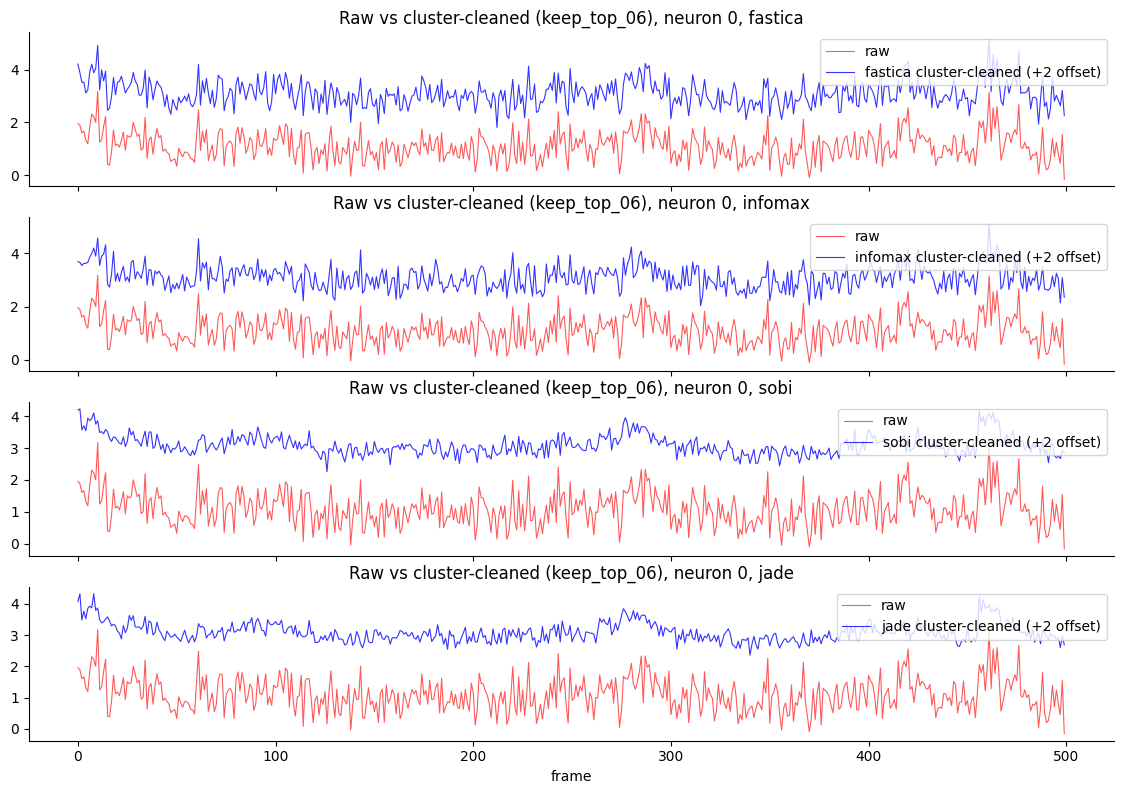

In [13]:
fig, axes = plt.subplots(len(results), 1, figsize=(14, 2.3 * len(results)), sharex=True)
if len(results) == 1:
    axes = [axes]
neuron_idx = 0
raw_vs_cleaned_offset = 2
for ax, (method, result) in zip(axes, results.items()):
    selection_id = primary_selection_id_by_method.get(method, "manual")
    raw_trace = traces[neuron_idx, time_slice]
    cleaned_trace = clustered_cleaned[method][time_slice, neuron_idx]
    ax.plot(raw_trace, lw=0.8, label="raw", color="red", alpha=0.65)
    ax.plot(
        cleaned_trace + raw_vs_cleaned_offset,
        lw=0.8,
        label=f"{method} cluster-cleaned (+{raw_vs_cleaned_offset:g} offset)",
        color="blue",
        alpha=0.8,
    )
    ax.set_title(f"Raw vs cluster-cleaned ({selection_id}), neuron {neuron_idx}, {method}")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("frame");


In [14]:
saved_paths_by_method = {}


def _cluster_members_for_selection(method, accepted_components):
    predictions = cluster_results[method]["predictions"]
    spectra = cluster_results[method]["spectra"]
    ranked = rank_clusters_by_mean_log_psd(
        spectra,
        predictions,
        sample_rate_hz,
        fmin=0.0,
        fmax=0.20,
        aggregate="peak",
    )
    rank_by_cluster = {int(row["cluster"]): int(row["rank"]) for row in ranked}
    accepted = set(int(value) for value in accepted_components)
    members = []
    for cluster_id in sorted(np.unique(predictions)):
        ic_indices = [int(idx) for idx in np.flatnonzero(predictions == cluster_id)]
        kept = [idx for idx in ic_indices if idx in accepted]
        rejected = [idx for idx in ic_indices if idx not in accepted]
        members.append(
            {
                "cluster": int(cluster_id),
                "n_ics": len(ic_indices),
                "ic_indices": ic_indices,
                "accepted_ic_indices": kept,
                "rejected_ic_indices": rejected,
                "peak_log_psd_rank_0_to_0p20_hz": rank_by_cluster.get(int(cluster_id)),
            }
        )
    return members


if SAVE_OUTPUTS:
    for method, result in results.items():
        method_dir = output_directory(
            method,
            result.dataset.data_name,
            PROJECT_ROOT,
            analysis_kind=OUTPUT_ANALYSIS_KIND,
            dataset_group=result.dataset.group,
        )
        saved_paths_by_method.setdefault(method, {})

        for selection in selection_plan_by_method[method]:
            selection_id = selection["selection_id"]
            is_primary = selection_id == primary_selection_id_by_method[method]
            cleaned_variant = clustered_cleaned_by_selection[method][selection_id]
            reject_components = reject_components_by_method_and_selection[method][selection_id]
            accepted_components = accepted_components_by_method_and_selection[method][selection_id]
            accepted_count = accepted_counts_by_method_and_selection[method][selection_id]

            if SELECTION_MODE == "incremental_ranked" and INCREMENTAL_SAVE_TO_SUBDIRS:
                variant_output_dir = method_dir / "incremental" / selection_id
            else:
                variant_output_dir = method_dir

            requested_selection = {
                "keep_clusters": [int(value) for value in selection.get("keep_clusters", [])],
                "reject_clusters": [int(value) for value in selection.get("reject_clusters", [])],
            }
            cluster_figure_paths = {
                label: str(path.relative_to(PROJECT_ROOT))
                for label, path in globals().get("cluster_figure_paths_by_method", {}).get(method, {}).items()
            }

            cleaned_paths = save_cleaned_trace_output(
                spec=result.dataset,
                method=method,
                traces=result.traces,
                cleaned=cleaned_variant,
                reject_components=reject_components,
                output_dir=variant_output_dir,
                metadata={
                    "source_decomposition_dir": str(result.output_dir.relative_to(PROJECT_ROOT)),
                    "selection_strategy": (
                        "spectral_cluster_selection_incremental"
                        if SELECTION_MODE == "incremental_ranked"
                        else "spectral_cluster_selection"
                    ),
                    "selection_mode": SELECTION_MODE,
                    "selection_id": selection_id,
                    "is_primary_selection": bool(is_primary),
                    "cluster_rank_order": cluster_rank_order_by_method[method],
                    "cluster_parameters": {
                        "n_clusters": int(N_CLUSTERS),
                        "feature_start_bin": int(CLUSTER_FEATURE_START_BIN),
                        "nperseg": int(CLUSTER_NPERSEG),
                        "noverlap": int(CLUSTER_NOVERLAP),
                        "random_state": int(CLUSTER_RANDOM_STATE),
                    },
                    "requested_selection": requested_selection,
                    "accepted_components": accepted_components,
                    "rejected_components": reject_components,
                    "cluster_figure_paths": cluster_figure_paths,
                },
            )
            selection_path = save_cluster_selection_output(
                spec=result.dataset,
                method=method,
                output_dir=variant_output_dir,
                selection={
                    "source_decomposition_dir": str(result.output_dir.relative_to(PROJECT_ROOT)),
                    "source_decomposition_metadata": source_metadata_by_method.get(method, {}),
                    "cleaned_trace_path": str(cleaned_paths["cleaned"].relative_to(PROJECT_ROOT)),
                    "cleaned_metadata_path": str(cleaned_paths["cleaned_metadata"].relative_to(PROJECT_ROOT)),
                    "selection_mode": SELECTION_MODE,
                    "selection_id": selection_id,
                    "is_primary_selection": bool(is_primary),
                    "cluster_rank_order": cluster_rank_order_by_method[method],
                    "cluster_parameters": {
                        "n_clusters": int(N_CLUSTERS),
                        "feature_start_bin": int(CLUSTER_FEATURE_START_BIN),
                        "nperseg": int(CLUSTER_NPERSEG),
                        "noverlap": int(CLUSTER_NOVERLAP),
                        "random_state": int(CLUSTER_RANDOM_STATE),
                    },
                    "requested_selection": requested_selection,
                    "accepted_components": accepted_components,
                    "rejected_components": reject_components,
                    "cluster_figure_paths": cluster_figure_paths,
                    "n_accepted_components": accepted_count,
                    "n_rejected_components": len(reject_components),
                    "clusters": _cluster_members_for_selection(method, accepted_components),
                },
            )
            saved_paths_by_method[method][selection_id] = {
                "cleaned": cleaned_paths["cleaned"],
                "cleaned_metadata": cleaned_paths["cleaned_metadata"],
                "cluster_selection": selection_path,
            }

            if (
                SELECTION_MODE == "incremental_ranked"
                and INCREMENTAL_SAVE_TO_SUBDIRS
                and INCREMENTAL_SAVE_PRIMARY_TO_CANONICAL
                and is_primary
            ):
                canonical_cleaned_paths = save_cleaned_trace_output(
                    spec=result.dataset,
                    method=method,
                    traces=result.traces,
                    cleaned=cleaned_variant,
                    reject_components=reject_components,
                    output_dir=method_dir,
                    metadata={
                        "source_decomposition_dir": str(result.output_dir.relative_to(PROJECT_ROOT)),
                        "selection_strategy": "spectral_cluster_selection_incremental_primary_alias",
                        "selection_mode": SELECTION_MODE,
                        "selection_id": selection_id,
                        "cluster_rank_order": cluster_rank_order_by_method[method],
                        "requested_selection": requested_selection,
                        "accepted_components": accepted_components,
                        "rejected_components": reject_components,
                    },
                )
                canonical_selection_path = save_cluster_selection_output(
                    spec=result.dataset,
                    method=method,
                    output_dir=method_dir,
                    selection={
                        "source_decomposition_dir": str(result.output_dir.relative_to(PROJECT_ROOT)),
                        "source_decomposition_metadata": source_metadata_by_method.get(method, {}),
                        "cleaned_trace_path": str(canonical_cleaned_paths["cleaned"].relative_to(PROJECT_ROOT)),
                        "cleaned_metadata_path": str(canonical_cleaned_paths["cleaned_metadata"].relative_to(PROJECT_ROOT)),
                        "selection_mode": SELECTION_MODE,
                        "selection_id": selection_id,
                        "saved_layout": "canonical_primary_alias",
                        "cluster_rank_order": cluster_rank_order_by_method[method],
                        "requested_selection": requested_selection,
                        "accepted_components": accepted_components,
                        "rejected_components": reject_components,
                        "n_accepted_components": accepted_count,
                        "n_rejected_components": len(reject_components),
                        "clusters": _cluster_members_for_selection(method, accepted_components),
                    },
                )
                saved_paths_by_method[method][f"{selection_id}__canonical"] = {
                    "cleaned": canonical_cleaned_paths["cleaned"],
                    "cleaned_metadata": canonical_cleaned_paths["cleaned_metadata"],
                    "cluster_selection": canonical_selection_path,
                }

for method, result in results.items():
    method_dir = output_directory(
        method,
        result.dataset.data_name,
        PROJECT_ROOT,
        analysis_kind=OUTPUT_ANALYSIS_KIND,
        dataset_group=result.dataset.group,
    )
    print(f"{method}: rank order = {cluster_rank_order_by_method.get(method)}")
    if method in saved_paths_by_method:
        method_rows = selection_df[selection_df["method"] == method]
        for _, row in method_rows.iterrows():
            selection_id = row["selection_id"]
            print(
                f"  {selection_id}: keep_clusters={row['keep_clusters']} "
                f"n_accepted={int(row['n_accepted'])} n_rejected={int(row['n_rejected'])}"
            )
            saved = saved_paths_by_method[method].get(selection_id)
            if saved is not None:
                for label, path in saved.items():
                    print(f"    {label}: {path.relative_to(PROJECT_ROOT)}")

        canonical_key = f"{primary_selection_id_by_method[method]}__canonical"
        if canonical_key in saved_paths_by_method[method]:
            print(f"  canonical_primary ({primary_selection_id_by_method[method]}):")
            for label, path in saved_paths_by_method[method][canonical_key].items():
                print(f"    {label}: {path.relative_to(PROJECT_ROOT)}")
    else:
        print(
            f"{method}: not saved; set SAVE_OUTPUTS = True after cluster selections are final "
            f"to write cleaned traces under {(method_dir / 'cleaned').relative_to(PROJECT_ROOT)}"
        )


fastica: rank order = [0, 5, 2, 1, 4, 6, 3]
  keep_top_01: keep_clusters=[0] n_accepted=77 n_rejected=767
    cleaned: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/incremental/keep_top_01/cleaned/cleaned_fastica_220127_F4_run2_fluorescence.npy
    cleaned_metadata: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/incremental/keep_top_01/cleaned/metadata_cleaned_fastica_220127_F4_run2_fluorescence.json
    cluster_selection: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/incremental/keep_top_01/clusters/cluster_selection_fastica_220127_F4_run2_fluorescence.json
  keep_top_02: keep_clusters=[0, 5] n_accepted=105 n_rejected=739
    cleaned: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/incremental/keep_top_02/cleaned/cleaned_fastica_220127_F4_run2_fluorescence.npy
    cleaned_metadata: outputs/linear/v2a-RSNs/220127_F4_run2_fluorescence/fastica/incremental/keep_top_02/cleaned/metadata_cleaned_fastica_220127_F4_run2_fluorescence.json
   